# Clausura Híbrida Óptima por Mínimos Cuadrados

[![Run in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github//TU_REPO/blob/main/RUTA/Transformer_Inrush_Optimal_Hybrid_Closure.ipynb)

# Transformador monofásico: clausura híbrida óptima por mínimos cuadrados

Este notebook construye una **clausura híbrida óptima** para aproximar el término no lineal

\[
\psi^{19}(t)
\]

usando una base híbrida impar e informada por trayectoria:

\[
\psi^{19}(t)\approx
c_1\,\psi(t)\,\psi_{ref}^{18}(t)
+
c_3\,\psi^3(t)\,\psi_{ref}^{16}(t)
+
c_5\,\psi^5(t)\,\psi_{ref}^{14}(t).
\]

Los coeficientes \(c_1,c_3,c_5\) se calculan por **mínimos cuadrados lineales**, ya que la aproximación es lineal en esos coeficientes.

## Objetivo

Comparar:

- clausura híbrida simple \(m=1\),
- clausura híbrida simple \(m=3\),
- clausura híbrida simple \(m=5\),
- y la **combinación óptima** ajustada en la base
  \[
  \{\psi\psi_{ref}^{18},\ \psi^3\psi_{ref}^{16},\ \psi^5\psi_{ref}^{14}\}.
  \]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import pandas as pd
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 1. Parámetros del caso base

In [ ]:
r1 = 0.192
r0 = 612.86
l1 = 0.0009

Vp = 110.0
freq_hz = 60.0
omega_num = 2*np.pi*freq_hz
phi0 = np.deg2rad(-42.97)

iin0 = 0.0
psi0 = 0.0

t0 = 0.0
tf = 0.20
npts = 6000
t_eval = np.linspace(t0, tf, npts)

def i_psi_exact(psi):
    return 0.7576*psi + 1.03e7*psi**19

def vp_func(t):
    return Vp*np.sin(omega_num*t + phi0)

## 2. Simulación original exacta

/tmp/ipykernel_1371/118087025.py:19: RuntimeWarning: overflow encountered in scalar power
  return 0.7576*psi + 1.03e7*psi**19


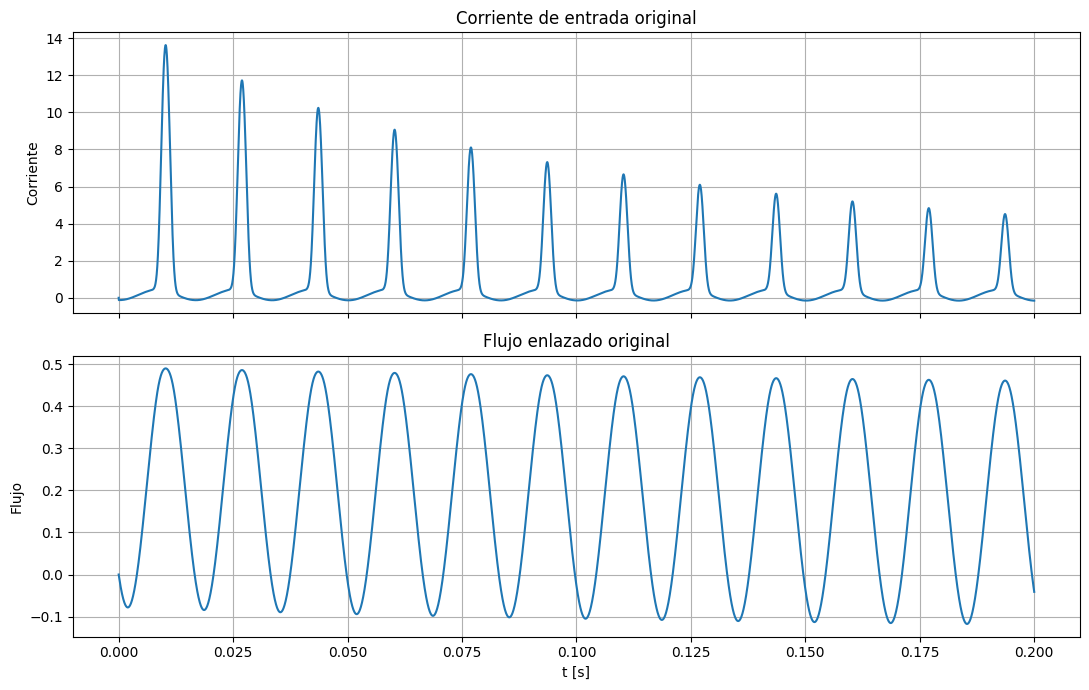

In [ ]:
def rhs_original(t, y):
    iin, psi = y
    ipsi = i_psi_exact(psi)
    diin = -((r1 + r0)/l1)*iin + (r0/l1)*ipsi + vp_func(t)/l1
    dpsi = r0*iin - r0*ipsi
    return [diin, dpsi]

sol_original = solve_ivp(
    rhs_original,
    (t0, tf),
    [iin0, psi0],
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10
)

t = sol_original.t
iin_ref = sol_original.y[0]
psi_ref = sol_original.y[1]

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(t, iin_ref)
ax[0].set_ylabel("Corriente")
ax[0].set_title("Corriente de entrada original")
ax[1].plot(t, psi_ref)
ax[1].set_ylabel("Flujo")
ax[1].set_xlabel("t [s]")
ax[1].set_title("Flujo enlazado original")
plt.tight_layout()
plt.show()

## 3. Referencia con factor transitorio

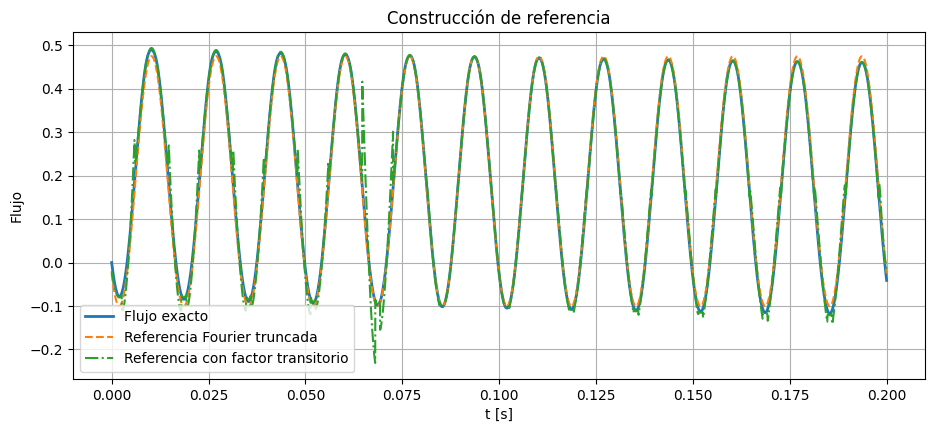

In [ ]:
def fit_fourier_series(t, y, omega, Nh):
    t = np.asarray(t)
    y = np.asarray(y)

    cols = [np.ones_like(t)]
    labels = [("a0", 0)]

    for k in range(1, Nh + 1):
        cols.append(np.cos(k * omega * t))
        labels.append(("a", k))
        cols.append(np.sin(k * omega * t))
        labels.append(("b", k))

    A = np.column_stack(cols)
    coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)
    return coeffs, labels

def eval_fourier_series(t, omega, coeffs, labels):
    t = np.asarray(t)
    y = np.zeros_like(t, dtype=float)
    for c, (kind, k) in zip(coeffs, labels):
        if kind == "a0":
            y += c
        elif kind == "a":
            y += c * np.cos(k * omega * t)
        elif kind == "b":
            y += c * np.sin(k * omega * t)
    return y

Nh = 3
coeffs_fourier, labels_fourier = fit_fourier_series(t, psi_ref, omega_num, Nh)
psi_per = eval_fourier_series(t, omega_num, coeffs_fourier, labels_fourier)

eps = 1e-6
ratio = np.abs(psi_ref) / np.maximum(np.abs(psi_per), eps)
window = 101
kernel = np.ones(window) / window
a_env = np.convolve(ratio, kernel, mode="same")
a_env = np.clip(a_env, 0.8, 2.5)

psi_ref_transient = a_env * psi_per

plt.figure(figsize=(11, 4.5))
plt.plot(t, psi_ref, label="Flujo exacto", linewidth=2.0)
plt.plot(t, psi_per, "--", label="Referencia Fourier truncada")
plt.plot(t, psi_ref_transient, "-.", label="Referencia con factor transitorio")
plt.xlabel("t [s]")
plt.ylabel("Flujo")
plt.title("Construcción de referencia")
plt.legend()
plt.show()

In [ ]:
psi_ref_transient_fun = interp1d(
    t, psi_ref_transient,
    kind="cubic",
    fill_value="extrapolate",
    bounds_error=False
)

## 4. Ajuste óptimo de los coeficientes c1, c3, c5

In [ ]:
def fit_optimal_hybrid_coeffs(psi, psi_ref_signal, t, weighted=False, early_time=0.03, early_weight=5.0):
    b1 = psi * (psi_ref_signal**18)
    b3 = (psi**3) * (psi_ref_signal**16)
    b5 = (psi**5) * (psi_ref_signal**14)

    A = np.column_stack([b1, b3, b5])
    y = psi**19

    if weighted:
        w = np.ones_like(t)
        w[t <= early_time] = early_weight
        W = np.sqrt(w)
        A = A * W[:, None]
        y = y * W

    coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)
    return coeffs

In [ ]:
c1, c3, c5 = fit_optimal_hybrid_coeffs(
    psi_ref,
    psi_ref_transient,
    t,
    weighted=True,
    early_time=0.03,
    early_weight=5.0
)

print("Coeficientes óptimos:")
print("c1 =", c1)
print("c3 =", c3)
print("c5 =", c5)

Coeficientes óptimos:
c1 = 1.394375310484633
c3 = -9.388496430817083
c5 = 8.993511269423788


Coeficientes óptimos:
c1 = 1.394375310484633
c3 = -9.388496430817083
c5 = 8.993511269423788

## 5. Ajuste local del término no lineal

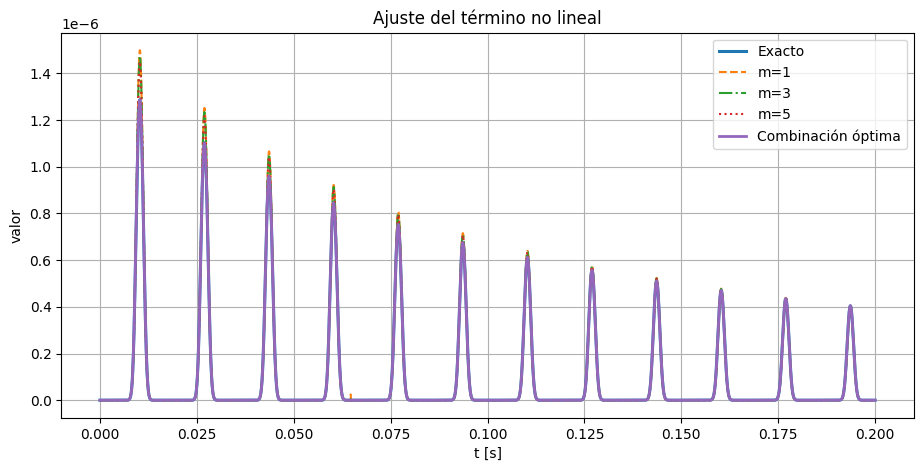

In [ ]:
nl_exact = psi_ref**19
nl_m1 = psi_ref * (psi_ref_transient**18)
nl_m3 = (psi_ref**3) * (psi_ref_transient**16)
nl_m5 = (psi_ref**5) * (psi_ref_transient**14)
nl_opt = c1*nl_m1 + c3*nl_m3 + c5*nl_m5

plt.figure(figsize=(11, 5))
plt.plot(t, nl_exact, label="Exacto", linewidth=2.2)
plt.plot(t, nl_m1, "--", label="m=1")
plt.plot(t, nl_m3, "-.", label="m=3")
plt.plot(t, nl_m5, ":", label="m=5")
plt.plot(t, nl_opt, label="Combinación óptima", linewidth=2.0)
plt.xlabel("t [s]")
plt.ylabel("valor")
plt.title("Ajuste del término no lineal")
plt.legend()
plt.show()

## 6. Simulación de clausuras simples y óptima

In [ ]:
def i_psi_hybrid_m(psi, psi_ref_t, m):
    return 0.7576*psi + 1.03e7 * (psi**m) * (psi_ref_t**(19 - m))

def i_psi_hybrid_optimal(psi, psi_ref_t, c1, c3, c5):
    return 0.7576*psi + 1.03e7 * (
        c1 * psi * (psi_ref_t**18)
        + c3 * (psi**3) * (psi_ref_t**16)
        + c5 * (psi**5) * (psi_ref_t**14)
    )

In [ ]:
def simulate_model(mode="m", m=1, coeffs=None):
    def rhs(t, y):
        iin, psi = y
        psi_r = float(psi_ref_transient_fun(t))

        if mode == "m":
            ipsi = i_psi_hybrid_m(psi, psi_r, m)
        elif mode == "opt":
            ipsi = i_psi_hybrid_optimal(psi, psi_r, *coeffs)
        else:
            raise ValueError("mode debe ser 'm' o 'opt'")

        diin = -((r1 + r0)/l1)*iin + (r0/l1)*ipsi + vp_func(t)/l1
        dpsi = r0*iin - r0*ipsi
        return [diin, dpsi]

    sol = solve_ivp(
        rhs,
        (t0, tf),
        [iin0, psi0],
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )
    return sol.y[0], sol.y[1]

In [ ]:
iin_m1, psi_m1 = simulate_model(mode="m", m=1)
iin_m3, psi_m3 = simulate_model(mode="m", m=3)
iin_m5, psi_m5 = simulate_model(mode="m", m=5)
iin_opt, psi_opt = simulate_model(mode="opt", coeffs=(c1, c3, c5))

## 7. Comparación global de la corriente

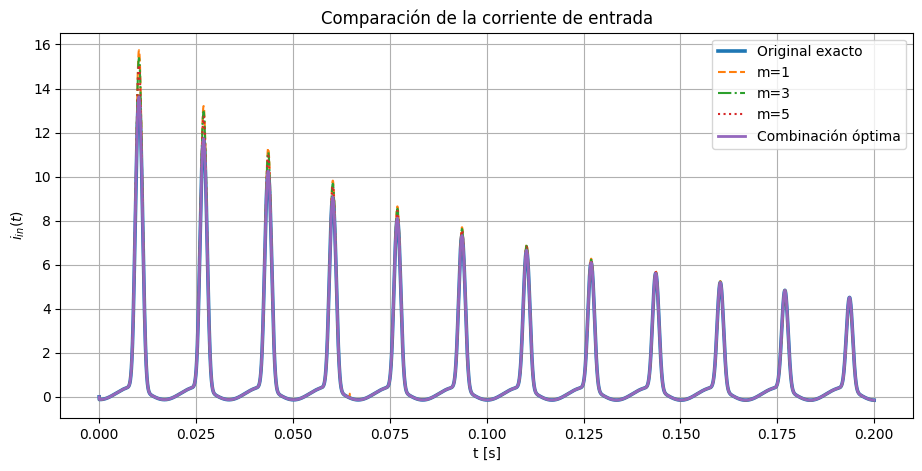

In [12]:
plt.figure(figsize=(11, 5))
plt.plot(t, iin_ref, label="Original exacto", linewidth=2.6)
plt.plot(t, iin_m1, "--", label="m=1")
plt.plot(t, iin_m3, "-.", label="m=3")
plt.plot(t, iin_m5, ":", label="m=5")
plt.plot(t, iin_opt, label="Combinación óptima", linewidth=2.0)
plt.xlabel("t [s]")
plt.ylabel(r"$i_{in}(t)$")
plt.title("Comparación de la corriente de entrada")
plt.legend()
plt.show()

## 8. Zoom de los primeros picos

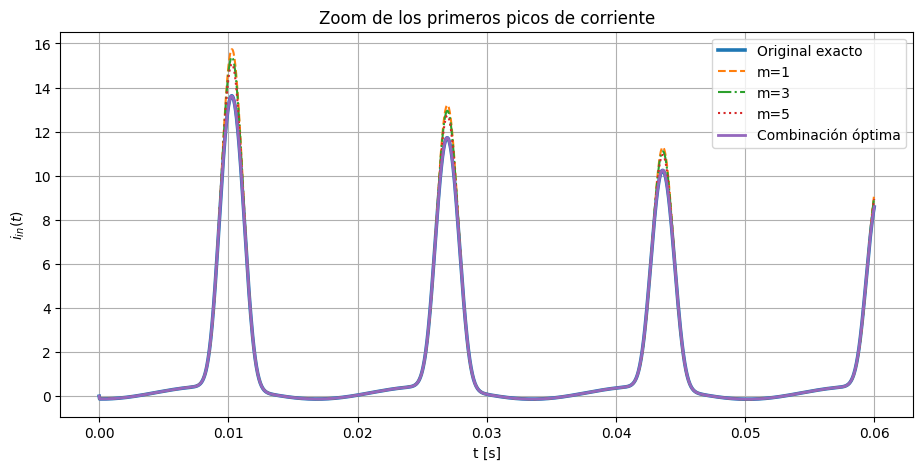

In [13]:
mask = (t >= 0.0) & (t <= 0.06)

plt.figure(figsize=(11, 5))
plt.plot(t[mask], iin_ref[mask], label="Original exacto", linewidth=2.6)
plt.plot(t[mask], iin_m1[mask], "--", label="m=1")
plt.plot(t[mask], iin_m3[mask], "-.", label="m=3")
plt.plot(t[mask], iin_m5[mask], ":", label="m=5")
plt.plot(t[mask], iin_opt[mask], label="Combinación óptima", linewidth=2.0)
plt.xlabel("t [s]")
plt.ylabel(r"$i_{in}(t)$")
plt.title("Zoom de los primeros picos de corriente")
plt.legend()
plt.show()

## 9. Métricas de error

In [14]:
peak_window = (t >= 0.0) & (t <= 0.015)

def metrics(i_approx):
    rms = np.sqrt(np.mean((iin_ref - i_approx)**2))
    max_err = np.max(np.abs(iin_ref - i_approx))
    first_peak_err = np.max(np.abs(iin_ref[peak_window] - i_approx[peak_window]))
    return rms, max_err, first_peak_err

rms1, max1, fp1 = metrics(iin_m1)
rms3, max3, fp3 = metrics(iin_m3)
rms5, max5, fp5 = metrics(iin_m5)
rms_opt, max_opt, fp_opt = metrics(iin_opt)

summary = pd.DataFrame({
    "modelo": ["m=1", "m=3", "m=5", "optima"],
    "RMS": [rms1, rms3, rms5, rms_opt],
    "max_err": [max1, max3, max5, max_opt],
    "first_peak_err": [fp1, fp3, fp5, fp_opt],
})
summary

,modelo,RMS,max_err,first_peak_err
0,m=1,0.202595,2.118794,2.118794
1,m=3,0.167989,1.761253,1.761253
2,m=5,0.138064,1.448666,1.448666
3,optima,0.002088,0.011444,0.011444


## 10. Curvas de métricas

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot([1, 3, 5], [rms1, rms3, rms5], marker="o", label="RMS")
plt.plot([1, 3, 5], [max1, max3, max5], marker="s", label="Error máximo")
plt.plot([1, 3, 5], [fp1, fp3, fp5], marker="^", label="Error primer pico")
plt.axhline(rms_opt, linestyle="--", label="RMS óptima")
plt.xlabel("m")
plt.ylabel("Error")
plt.title("Familia híbrida impar vs. combinación óptima")
plt.legend()
plt.show()

## 11. Exportación

In [ ]:
outdir = Path("optimal_hybrid_closure_export")
outdir.mkdir(exist_ok=True)

df = pd.DataFrame({
    "t": t,
    "iin_ref": iin_ref,
    "iin_m1": iin_m1,
    "iin_m3": iin_m3,
    "iin_m5": iin_m5,
    "iin_opt": iin_opt,
    "psi_ref": psi_ref,
    "psi_ref_transient": psi_ref_transient,
    "psi_m1": psi_m1,
    "psi_m3": psi_m3,
    "psi_m5": psi_m5,
    "psi_opt": psi_opt,
})
csv_path = outdir / "optimal_hybrid_closure_compare.csv"
df.to_csv(csv_path, index=False)

summary_path = outdir / "optimal_hybrid_closure_summary.csv"
summary.to_csv(summary_path, index=False)

coeffs_path = outdir / "optimal_hybrid_coeffs.csv"
pd.DataFrame({"c1": [c1], "c3": [c3], "c5": [c5]}).to_csv(coeffs_path, index=False)

print("Archivos exportados:")
print(csv_path.resolve())
print(summary_path.resolve())
print(coeffs_path.resolve())

## 12. Lectura conceptual

Este experimento sugiere que la familia híbrida impar puede mejorarse aún más si,
en lugar de escoger un único término psi^m * psi_ref^(19-m), se ajusta una combinación óptima
dentro de una base híbrida liftable.

Eso abre una vía interesante:
- no aproximar psi^19 por un polinomio impar puro,
- tampoco por una sola clausura híbrida,
- sino por una base híbrida impar informada por trayectoria,
  cuyos coeficientes se ajustan por mínimos cuadrados.

### Lectura de la clausura óptima

La combinación óptima de términos híbridos impares reduce de manera muy significativa el error respecto a las clausuras individuales \(m=1,3,5\). Esto sugiere que, para este tipo de no linealidad extrema, una base híbrida impar informada por trayectoria constituye una estructura aproximante mucho más poderosa que una única clausura monomial. En otras palabras, la referencia programada y la no linealidad explícita no compiten: se complementan.

In [15]:
# =========================================================
# Ajuste en un intervalo y validación en otro
# =========================================================

t_fit_end = 0.03

fit_mask = t <= t_fit_end
val_mask = t > t_fit_end

print("Puntos de ajuste:", np.sum(fit_mask))
print("Puntos de validación:", np.sum(val_mask))

Puntos de ajuste: 900
Puntos de validación: 5100


In [16]:
def fit_optimal_hybrid_coeffs_on_mask(psi, psi_ref_signal, t, mask, weighted=False, early_time=0.03, early_weight=5.0):
    psi_fit = psi[mask]
    psi_ref_fit = psi_ref_signal[mask]
    t_fit = t[mask]

    b1 = psi_fit * (psi_ref_fit**18)
    b3 = (psi_fit**3) * (psi_ref_fit**16)
    b5 = (psi_fit**5) * (psi_ref_fit**14)

    A = np.column_stack([b1, b3, b5])
    y = psi_fit**19

    if weighted:
        w = np.ones_like(t_fit)
        w[t_fit <= early_time] = early_weight
        W = np.sqrt(w)
        A = A * W[:, None]
        y = y * W

    coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)
    return coeffs

c1_fit, c3_fit, c5_fit = fit_optimal_hybrid_coeffs_on_mask(
    psi_ref,
    psi_ref_transient,
    t,
    fit_mask,
    weighted=True,
    early_time=0.03,
    early_weight=5.0
)

print("Coeficientes ajustados en la ventana de ajuste:")
print("c1 =", c1_fit)
print("c3 =", c3_fit)
print("c5 =", c5_fit)

Coeficientes ajustados en la ventana de ajuste:
c1 = 26.02947459652286
c3 = -59.04829575920897
c5 = 34.01882645503913


In [17]:
def i_psi_hybrid_optimal_fit(psi, psi_ref_t, c1, c3, c5):
    return 0.7576*psi + 1.03e7 * (
        c1 * psi * (psi_ref_t**18)
        + c3 * (psi**3) * (psi_ref_t**16)
        + c5 * (psi**5) * (psi_ref_t**14)
    )

def simulate_model_with_fixed_coeffs(c1, c3, c5):
    def rhs(t, y):
        iin, psi = y
        psi_r = float(psi_ref_transient_fun(t))
        ipsi = i_psi_hybrid_optimal_fit(psi, psi_r, c1, c3, c5)

        diin = -((r1 + r0)/l1)*iin + (r0/l1)*ipsi + vp_func(t)/l1
        dpsi = r0*iin - r0*ipsi
        return [diin, dpsi]

    sol = solve_ivp(
        rhs,
        (t0, tf),
        [iin0, psi0],
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )
    return sol.y[0], sol.y[1]

iin_opt_fitwindow, psi_opt_fitwindow = simulate_model_with_fixed_coeffs(c1_fit, c3_fit, c5_fit)

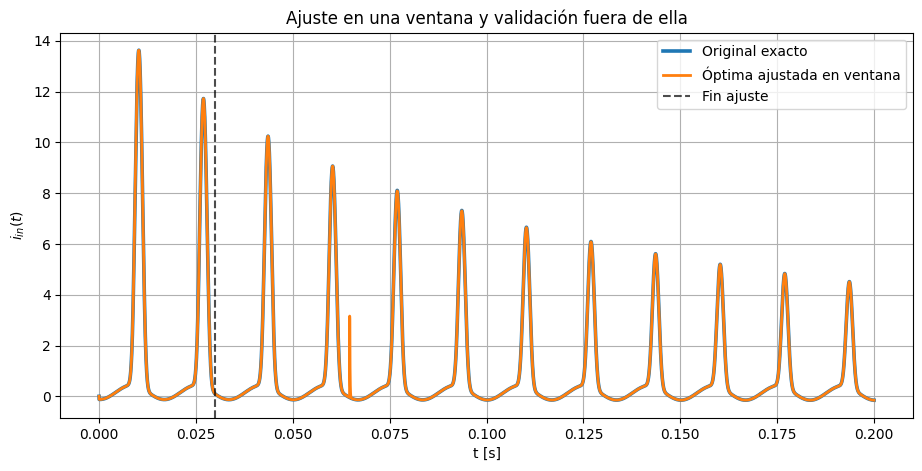

In [18]:
plt.figure(figsize=(11, 5))
plt.plot(t, iin_ref, label="Original exacto", linewidth=2.6)
plt.plot(t, iin_opt_fitwindow, label="Óptima ajustada en ventana", linewidth=2.0)
plt.axvline(t_fit_end, color="k", linestyle="--", alpha=0.7, label="Fin ajuste")
plt.xlabel("t [s]")
plt.ylabel(r"$i_{in}(t)$")
plt.title("Ajuste en una ventana y validación fuera de ella")
plt.legend()
plt.show()

In [19]:
def metrics_on_mask(i_ref, i_approx, mask):
    err = np.abs(i_ref[mask] - i_approx[mask])
    rms = np.sqrt(np.mean((i_ref[mask] - i_approx[mask])**2))
    max_err = np.max(err)
    return rms, max_err

rms_fit, max_fit = metrics_on_mask(iin_ref, iin_opt_fitwindow, fit_mask)
rms_val, max_val = metrics_on_mask(iin_ref, iin_opt_fitwindow, val_mask)

print("=== Métricas de la clausura óptima ajustada en ventana ===")
print(f"Ajuste      -> RMS = {rms_fit:.6f}, max_err = {max_fit:.6f}")
print(f"Validación  -> RMS = {rms_val:.6f}, max_err = {max_val:.6f}")

=== Métricas de la clausura óptima ajustada en ventana ===
Ajuste      -> RMS = 0.000116, max_err = 0.001670
Validación  -> RMS = 0.070748, max_err = 3.206770


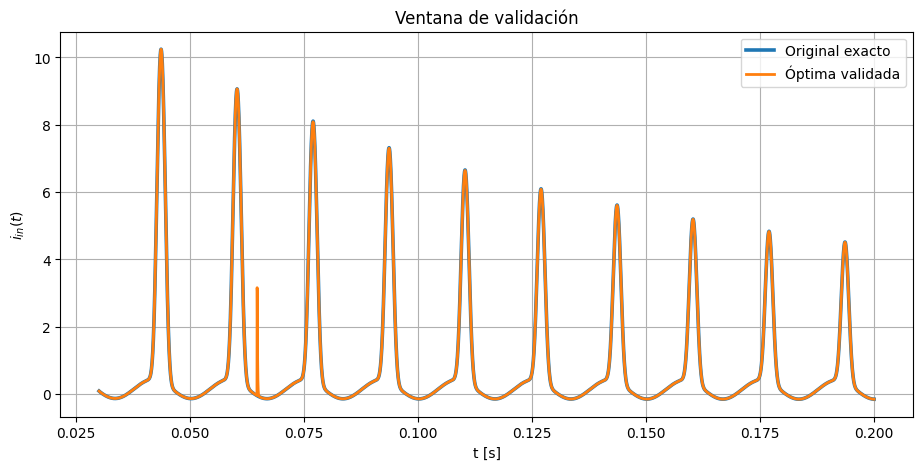

In [20]:
plt.figure(figsize=(11, 5))
plt.plot(t[val_mask], iin_ref[val_mask], label="Original exacto", linewidth=2.6)
plt.plot(t[val_mask], iin_opt_fitwindow[val_mask], label="Óptima validada", linewidth=2.0)
plt.xlabel("t [s]")
plt.ylabel(r"$i_{in}(t)$")
plt.title("Ventana de validación")
plt.legend()
plt.show()

### Lectura del experimento de validación

La separación entre ventana de ajuste y ventana de validación muestra que la clausura híbrida óptima no actúa únicamente como interpolante local. Aunque su precisión disminuye fuera del intervalo donde se ajustaron los coeficientes, la respuesta validada conserva con buena fidelidad la estructura temporal de los picos, la envolvente decreciente y la dinámica oscilatoria global. Esto sugiere que la base híbrida impar informada por trayectoria captura una estructura parcialmente transferible del sistema, lo cual la convierte en una candidata prometedora para construir modelos transformados de orden reducido con valor predictivo moderado.